In [2]:
from google.colab import files
uploaded = files.upload()

Saving Railway_station_zone-category_wise_list.pdf to Railway_station_zone-category_wise_list.pdf


# DATA EXTRACTION

In [3]:
!pip install pdfplumber

import pdfplumber
import pandas as pd


path = "/content/Railway_station_zone-category_wise_list.pdf"

# --- Step 3: one-page test ---
with pdfplumber.open(path) as pdf:
    test_page = pdf.pages[0]
    tables = test_page.extract_tables()
    print(tables[0][:5])   # inspect first few rows — do columns look right?

# --- Step 4: loop through every page and collect rows ---
header = ["S No", "Station Name", "Station Code", "Station Category",
          "Division", "Zone", "District", "State"]

raw_rows = []
with pdfplumber.open(path) as pdf:
    print("Total pages:", len(pdf.pages))
    for i, page in enumerate(pdf.pages):
        tables = page.extract_tables()
        if not tables:
            print(f"Page {i+1}: NO TABLE FOUND")  # flag pages that failed
            continue
        for t in tables:
            raw_rows.extend(t)

print("Total raw rows (incl. repeated headers):", len(raw_rows))

# --- Step 5: clean rows ---
data_rows = []
for r in raw_rows:
    r_clean = [c.replace("\n", " ").strip() if c else "" for c in r]
    if r_clean[0].strip().lower() == "s no":   # skip repeated per-page header
        continue
    data_rows.append(r_clean)

# --- Step 6: load into DataFrame and validate ---
df = pd.DataFrame(data_rows, columns=header)

nums = pd.to_numeric(df["S No"], errors="coerce")
print("Non-numeric S No values:", nums.isna().sum())
print("Duplicated S No values:", nums.duplicated().sum())
expected = set(range(1, int(nums.max()) + 1))
missing = expected - set(nums.dropna().astype(int))
print("Missing S No values:", sorted(missing))

print("\nEmpty cells per column:")
print((df == "").sum())

# --- Step 7: export ---
df.to_csv("output.csv", index=False)
print("Saved", len(df), "rows to output.csv")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 94.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
[['S No', 'Station Name', 'Station Code', 'Station\nCategory', 'Division', 'Zone', 'District', 'State'], ['1', 'BHORAS BUDRUKH', 'BFJ', 'HG2', 'BHUSAWAL', 'CR', 'JALGAON', 'MAHARASHTRA'], ['2', 'JAMNER', 'JMNR', 'HG2', 'BHUSAWAL', 'CR', 'JALGAON', 'MAHARASHTRA'], ['3', 'ANJANGAON', 'ANJ', 'HG3', 'BHUSAWAL', 'CR', 'AMRAVATI', 'MAHARASHTRA'], ['4', 'BANOSA', 'BASA', 'HG3', 'B

In [4]:
df.shape

(8477, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8477 entries, 0 to 8476
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S No              8477 non-null   object
 1   Station Name      8477 non-null   object
 2   Station Code      8477 non-null   object
 3   Station Category  8477 non-null   object
 4   Division          8477 non-null   object
 5   Zone              8477 non-null   object
 6   District          8477 non-null   object
 7   State             8477 non-null   object
dtypes: object(8)
memory usage: 529.9+ KB


# Data Cleaning

In [6]:
df.isnull().sum()

,0
S No,0
Station Name,0
Station Code,0
Station Category,0
Division,0
Zone,0
District,0
State,0


In [7]:
print(df['Station Name'].nunique())
print(df['Station Code'].nunique())
print(df['Station Category'].nunique())
print(df['Division'].nunique())
print(df['Zone'].nunique())
print(df['District'].nunique())
print(df['State'].nunique())



8442
8441
12
64
16
596
35


We have checked the unique values in all the feature in the CSV file  and there seems to be 3 null values in the District feature as blanks

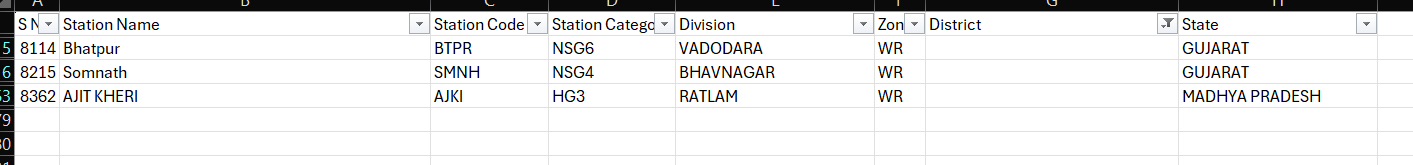





Even though we have null values in our dataset it's still showing no null values  beacuse, Those 3 District cells aren't actual NaN — they're empty strings ("")

In [8]:
# Check what's really going on
print(repr(df.loc[8113, 'District']))  # see the actual value

# Replace both NaN and empty/whitespace strings with 'Unknown'
df['District'] = df['District'].replace(r'^\s*$', 'Unknown', regex=True)
df['District'] = df['District'].fillna('Unknown')  # just in case any real NaN exist too

# Verify
print((df['District'] == 'Unknown').sum())
print(df[df['S No'].astype(str).isin(['8114','8215','8362'])])

''
3
      S No Station Name Station Code Station Category   Division Zone  \
8113  8114      Bhatpur         BTPR             NSG6   VADODARA   WR   
8214  8215      Somnath         SMNH             NSG4  BHAVNAGAR   WR   
8361  8362   AJIT KHERI         AJKI              HG3     RATLAM   WR   

     District           State  
8113  Unknown         GUJARAT  
8214  Unknown         GUJARAT  
8361  Unknown  MADHYA PRADESH  


In [9]:
df['S No'] = df['S No'].astype(int)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8477 entries, 0 to 8476
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S No              8477 non-null   int64 
 1   Station Name      8477 non-null   object
 2   Station Code      8477 non-null   object
 3   Station Category  8477 non-null   object
 4   Division          8477 non-null   object
 5   Zone              8477 non-null   object
 6   District          8477 non-null   object
 7   State             8477 non-null   object
dtypes: int64(1), object(7)
memory usage: 529.9+ KB


Now we will check the duplicates, for checking the duplicated we will sort it via station code because in Indian railways stations have the exact same station code us rare. So if there is any duplicated value then can be a data entry mistake or any ther mistaek

In [11]:
# Confirm Station Code has no accidental duplicates:
df['Station Code'].duplicated().sum()

np.int64(36)

In [12]:
dupe_codes = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
print(dupe_codes[['S No','Station Name','Station Code','Division','Zone', 'District', 'State']].to_string())

      S No           Station Name Station Code    Division Zone            District           State
1422  1423          BARHARA KOTHI         BAKT  SAMASTIPUR  ECR              PURNEA           BIHAR
1459  1460        BARHARA KOTHI F         BAKT  SAMASTIPUR  ECR           MADHEPURA           BIHAR
7609  7610                   BARA         BARA    JABALPUR  WCR             SHAHDOL  MADHYA PRADESH
5059  5060                 BILARA         BARA     JODHPUR  NWR             JODHPUR       RAJASTHAN
1467  1468                 BUDHMA         BDMA  SAMASTIPUR  ECR           MADHEPURA           BIHAR
1468  1469                 BUDHMA         BDMA  SAMASTIPUR  ECR           MADHEPURA           BIHAR
1461  1462        BHAGWANPURDESUA         BGDS  SAMASTIPUR  ECR          SAMASTIPUR           BIHAR
1460  1461       BHAGWANPUR DESUA         BGDS  SAMASTIPUR  ECR          SAMASTIPUR           BIHAR
1419  1420              BADLAGHAT          BHB  SAMASTIPUR  ECR            KHAGARIA           BIHAR


As we see there are some data cleaning needed in the data.

So first we will convert all the alphabets in Upper case

In [13]:
#UPER CASE
text_cols = ['Station Name', 'District', 'State', 'Division', 'Zone']
for col in text_cols:
    df[col] = df[col].str.strip().str.upper()

In [14]:
dupe_codes = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
print(dupe_codes[['S No','Station Name','Station Code','Division','Zone','District']].to_string())

      S No           Station Name Station Code    Division Zone            District
1422  1423          BARHARA KOTHI         BAKT  SAMASTIPUR  ECR              PURNEA
1459  1460        BARHARA KOTHI F         BAKT  SAMASTIPUR  ECR           MADHEPURA
7609  7610                   BARA         BARA    JABALPUR  WCR             SHAHDOL
5059  5060                 BILARA         BARA     JODHPUR  NWR             JODHPUR
1467  1468                 BUDHMA         BDMA  SAMASTIPUR  ECR           MADHEPURA
1468  1469                 BUDHMA         BDMA  SAMASTIPUR  ECR           MADHEPURA
1461  1462        BHAGWANPURDESUA         BGDS  SAMASTIPUR  ECR          SAMASTIPUR
1460  1461       BHAGWANPUR DESUA         BGDS  SAMASTIPUR  ECR          SAMASTIPUR
1419  1420              BADLAGHAT          BHB  SAMASTIPUR  ECR            KHAGARIA
1418  1419             BADLA GHAT          BHB  SAMASTIPUR  ECR            KHAGARIA
1398  1399      BAPUDHAM MOTIHARI         BMKI  SAMASTIPUR  ECR            M

There are some  mapping mistake like

'W CHAMPARAN': 'PASHCHIM CHAMPARAN'

'E. CHAMPARAN': 'PURBI CHAMPARAN',

'PURNIA': 'PURNEA' -- spelling mistake




In [15]:
district_map = {
    'W CHAMPARAN': 'PASHCHIM CHAMPARAN',
    'E. CHAMPARAN': 'PURBI CHAMPARAN',
    'PURNIA': 'PURNEA',
}
df['District'] = df['District'].replace(district_map)

In [16]:
df = df.drop_duplicates(subset=['Station Code', 'Station Name'], keep='first')


We droped those rows where station code + station name is same.

We made a subset with both station code and station name. Then dropping those rows where it's same

In [17]:
print("After:", df.duplicated(subset=['Station Code']).sum())
print("New shape:", df.shape)

After: 12
New shape: (8453, 8)


So we have dropped 24 rows

In [18]:
dupe_codes = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
print(dupe_codes[['S No','Station Name','Station Code','Division','Zone','District']].to_string())

      S No           Station Name Station Code    Division Zone            District
1459  1460        BARHARA KOTHI F         BAKT  SAMASTIPUR  ECR           MADHEPURA
1422  1423          BARHARA KOTHI         BAKT  SAMASTIPUR  ECR              PURNEA
7609  7610                   BARA         BARA    JABALPUR  WCR             SHAHDOL
5059  5060                 BILARA         BARA     JODHPUR  NWR             JODHPUR
1461  1462        BHAGWANPURDESUA         BGDS  SAMASTIPUR  ECR          SAMASTIPUR
1460  1461       BHAGWANPUR DESUA         BGDS  SAMASTIPUR  ECR          SAMASTIPUR
1418  1419             BADLA GHAT          BHB  SAMASTIPUR  ECR            KHAGARIA
1419  1420              BADLAGHAT          BHB  SAMASTIPUR  ECR            KHAGARIA
1395  1396               DARBANGA          DBG  SAMASTIPUR  ECR           DARBHANGA
1396  1397          DARBHANGA JN.          DBG  SAMASTIPUR  ECR           DARBHANGA
7013  7014          KATTUR (HALT)         KTTR      TRICHY   SR     TIRUCHIR

ANother issue we founnd is


*  BHAGWANPUR DESUA

*  BHAGWANPURDESUA

THese are the true duplicates. another normalization issue.




In [19]:
# Bucket 1: true duplicates — normalize name (remove spaces, uppercase) and dedupe
# where Station Code AND normalized name AND District all match
df['Name_Normalized'] = df['Station Name'].str.replace(' ', '', regex=False).str.replace('.', '', regex=False).str.upper()

# Preview what will be treated as duplicate under this rule
check = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
dupes_to_review = check[check.duplicated(subset=['Station Code','Name_Normalized','District'], keep=False)]
print(dupes_to_review[['S No','Station Name','Station Code','District']].to_string())

# Keep the row with the longer/more complete Station Name (e.g. "SAHARSA JN." over "SAHARSA")
df['name_len'] = df['Station Name'].str.len()
df = df.sort_values('name_len', ascending=False)
df = df.drop_duplicates(subset=['Station Code','Name_Normalized','District'], keep='first')
df = df.drop(columns=['Name_Normalized','name_len']).sort_values('S No').reset_index(drop=True)

print("Shape after Bucket 1 cleanup:", df.shape)

# Re-check what's left — this should now only show Bucket 2 (genuine) + Bucket 3 (ambiguous)
remaining = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
print(remaining[['S No','Station Name','Station Code','Division','Zone','District']].to_string())

      S No      Station Name Station Code    District
1461  1462   BHAGWANPURDESUA         BGDS  SAMASTIPUR
1460  1461  BHAGWANPUR DESUA         BGDS  SAMASTIPUR
1418  1419        BADLA GHAT          BHB    KHAGARIA
1419  1420         BADLAGHAT          BHB    KHAGARIA
1437  1438     LAHERIA SARAI          LSI   DARBHANGA
1438  1439      LAHERIASARAI          LSI   DARBHANGA
Shape after Bucket 1 cleanup: (8450, 8)
      S No           Station Name Station Code    Division Zone            District
1445  1460        BARHARA KOTHI F         BAKT  SAMASTIPUR  ECR           MADHEPURA
1415  1423          BARHARA KOTHI         BAKT  SAMASTIPUR  ECR              PURNEA
7582  7610                   BARA         BARA    JABALPUR  WCR             SHAHDOL
5032  5060                 BILARA         BARA     JODHPUR  NWR             JODHPUR
1395  1396               DARBANGA          DBG  SAMASTIPUR  ECR           DARBHANGA
1396  1397          DARBHANGA JN.          DBG  SAMASTIPUR  ECR           DARB

In [20]:
# Manually resolve these two remaining pairs — keep the more complete/correct name
df = df[~((df['Station Code'] == 'SBM') & (df['Station Name'] == 'SONBERSA KACCHERI'))]
df = df[~((df['Station Code'] == 'SHC') & (df['Station Name'] == 'SAHARSA'))]

df = df.reset_index(drop=True)
print("Shape now:", df.shape)

# Final check — anything still duplicated on Station Code?
final_check = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
print(final_check[['S No','Station Name','Station Code','Division','Zone','District']].to_string())

Shape now: (8448, 8)
      S No           Station Name Station Code    Division Zone            District
1414  1423          BARHARA KOTHI         BAKT  SAMASTIPUR  ECR              PURNEA
1443  1460        BARHARA KOTHI F         BAKT  SAMASTIPUR  ECR           MADHEPURA
5030  5060                 BILARA         BARA     JODHPUR  NWR             JODHPUR
7580  7610                   BARA         BARA    JABALPUR  WCR             SHAHDOL
1395  1396               DARBANGA          DBG  SAMASTIPUR  ECR           DARBHANGA
1396  1397          DARBHANGA JN.          DBG  SAMASTIPUR  ECR           DARBHANGA
5561  5591                 KOTTUR         KTTR   HYDERABAD  SCR         MAHBUBNAGAR
6984  7014          KATTUR (HALT)         KTTR      TRICHY   SR     TIRUCHIRAPPALLI
1406  1412           NARKATIAGANJ          NKE  SAMASTIPUR  ECR  PASHCHIM CHAMPARAN
1407  1413       NARKATIAGANJ JN.          NKE  SAMASTIPUR  ECR  PASHCHIM CHAMPARAN
1430  1445              RAMGARHWA          RGH  SAMASTI

Here we have dropped 3 rows and rest of the duplicate station code are genuine diffrent stations.

But here is 1 issue Spelling mistake and shorter/less standard name issue.

*   DARBANGA          
*   DARBHANGA JN.

*   NARKATIAGANJ
*  NARKATIAGANJ JN.

So we will keep the more standerd names

In [21]:
# Drop the shorter/less standard name, keep the more complete one
df = df[~((df['Station Code'] == 'DBG') & (df['Station Name'] == 'DARBANGA'))]
df = df[~((df['Station Code'] == 'NKE') & (df['Station Name'] == 'NARKATIAGANJ'))]

df = df.reset_index(drop=True)
print("Shape now:", df.shape)

# Final check
final_check = df[df['Station Code'].duplicated(keep=False)].sort_values('Station Code')
print(final_check[['S No','Station Name','Station Code','Division','Zone','District']].to_string())

Shape now: (8446, 8)
      S No           Station Name Station Code    Division Zone         District
1412  1423          BARHARA KOTHI         BAKT  SAMASTIPUR  ECR           PURNEA
1441  1460        BARHARA KOTHI F         BAKT  SAMASTIPUR  ECR        MADHEPURA
5028  5060                 BILARA         BARA     JODHPUR  NWR          JODHPUR
7578  7610                   BARA         BARA    JABALPUR  WCR          SHAHDOL
5559  5591                 KOTTUR         KTTR   HYDERABAD  SCR      MAHBUBNAGAR
6982  7014          KATTUR (HALT)         KTTR      TRICHY   SR  TIRUCHIRAPPALLI
1428  1445              RAMGARHWA          RGH  SAMASTIPUR  ECR         MOTIHARI
1429  1446            RAMGARHWA F          RGH  SAMASTIPUR  ECR  PURBI CHAMPARAN
2902  2933   SITAPUR KUTCHERY HAL         STRK     LUCKNOW  NER          SITAPUR
4296  4328  SITAPUR KUTCHERY HALT         STRK   MORADABAD   NR          SITAPUR


In [22]:
# 1. Any remaining full duplicate rows (not just Station Code)?
print("Full duplicate rows:", df.duplicated().sum())

# 2. Final overview
print(df.shape)
print(df.isna().sum())
print(df['Station Category'].unique())
print(df['Zone'].nunique(), "zones")
print(df['Division'].nunique(), "divisions")

Full duplicate rows: 0
(8446, 8)
S No                0
Station Name        0
Station Code        0
Station Category    0
Division            0
Zone                0
District            0
State               0
dtype: int64
['HG2' 'HG3' 'NSG2' 'NSG3' 'NSG4' 'NSG5' 'NSG6' 'NSG1' 'SG1' 'SG2' 'SG3'
 'HG1']
16 zones
64 divisions


# Feature Engineering


In [27]:
# 1. Category_Rank — numeric hierarchy level (1 = most important, 12 = least)
rank_dict = {
    'HG1': 1, 'HG2': 2, 'HG3': 3,
    'NSG1': 4, 'NSG2': 5, 'NSG3': 6, 'NSG4': 7, 'NSG5': 8, 'NSG6': 9,
    'SG1': 10, 'SG2': 11, 'SG3': 12
}
df['Category_Rank'] = df['Station Category'].map(rank_dict)

# 2. Division_Station_Count — how many stations exist in each station's division
df['Division_Station_Count'] = df.groupby('Division')['Station Code'].transform('count')

# 3. Zone_Share_% — what % of all stations belong to each station's zone
zone_counts = df['Zone'].value_counts(normalize=True) * 100
df['Zone_Share_%'] = df['Zone'].map(zone_counts).round(2)

# Sanity check
print(df[['Station Name','Station Category','Category_Rank','Division','Division_Station_Count','Zone','Zone_Share_%']].head(10))
print("\nAny unmapped categories?", df['Category_Rank'].isna().sum())

           Station Name Station Category  Category_Rank  Division  \
0        BHORAS BUDRUKH              HG2              2  BHUSAWAL   
1                JAMNER              HG2              2  BHUSAWAL   
2             ANJANGAON              HG3              3  BHUSAWAL   
3                BANOSA              HG3              3  BHUSAWAL   
4             BHADSIVNI              HG3              3  BHUSAWAL   
5              BHAGDARA              HG3              3  BHUSAWAL   
6              BORVIHIR              HG3              3  BHUSAWAL   
7                CHAMAK              HG3              3  BHUSAWAL   
8  DARWHA MOTI BAGH JN.              HG3              3  BHUSAWAL   
9            KAPUSTALNI              HG3              3  BHUSAWAL   

   Division_Station_Count Zone  Zone_Share_%  
0                     118   CR           5.7  
1                     118   CR           5.7  
2                     118   CR           5.7  
3                     118   CR           5.7  
4    

*  **Category_Rank:-** Converts Station Category (HG1-3, NSG1-6, SG1-3) into a numeric rank so you can sort, average, and compare hierarchy levels quantitatively — not just count them as text categories.

* **Division Station Count:**-  Adds the total number of stations in each station's Division as a column — turns your groupby result into a reusable per-row field for filtering, sorting, and visualization.

* **Zone Share % (of national total):-** Calculates what percentage of all 8,446 stations belong to each station's Zone

# ANALYSIS and Vizualization



In [29]:
## Insight 1: which zones have the highest concentration of top-tier stations
df.groupby('Zone')['Category_Rank'].mean().sort_values(ascending=False)

,Category_Rank
Zone,
ER,8.239726
WCR,7.989899
CR,7.796258
SR,7.561437
ECOR,7.552469
SCR,7.541259
NFR,7.497317
WR,7.296687
NWR,7.210345


In [25]:
## Insight 2: To show the largest divisions based on station count
df.groupby('Division')['Division_Station_Count'].first().sort_values(ascending=False).head(10)

,Division_Station_Count
Division,
LUCKNOW,355
NAGPUR,271
FEROZPUR,249
DELHI,236
DANAPUR,219
SEALDAH,206
BANARAS,203
MORADABAD,199
SAMASTIPUR,198


LUCKNOW Devision have highest number of station count

/tmp/ipykernel_777/4115452969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_divisions.values, y=top_divisions.index, palette="mako")


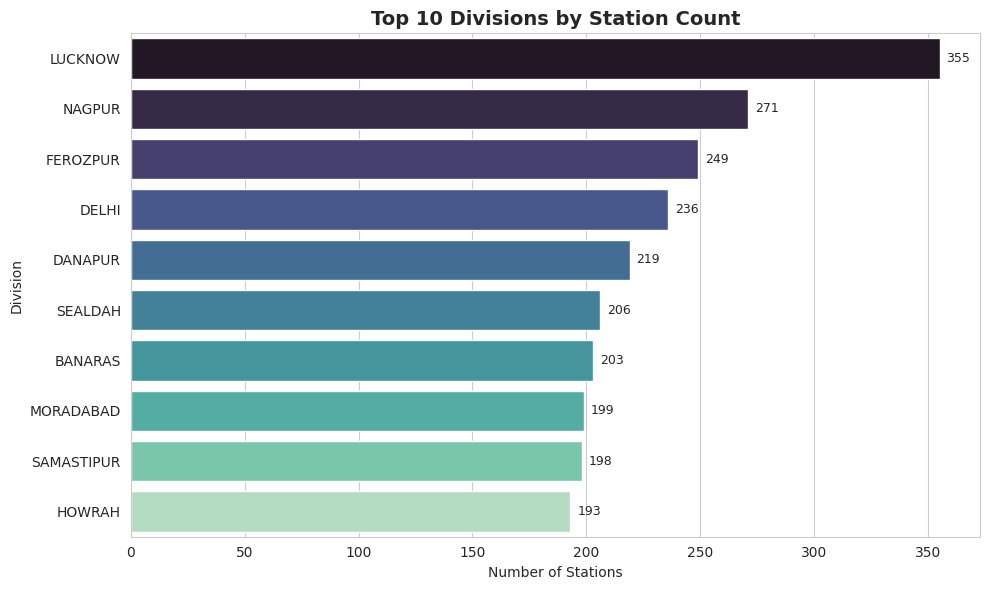

In [36]:
# 3. Top 10 Divisions by station count
top_divisions = df.groupby('Division')['Station Code'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_divisions.values, y=top_divisions.index, palette="mako")
plt.title("Top 10 Divisions by Station Count", fontsize=14, weight='bold')
plt.xlabel("Number of Stations")
plt.ylabel("Division")
for i, v in enumerate(top_divisions.values):
    plt.text(v + 3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig("top_divisions.png", dpi=150)
plt.show()

In [26]:
## Insight 3: Which zones have the highest share of the network in our dataset

df.groupby('Zone')['Zone_Share_%'].first().sort_values(ascending=False)

,Zone_Share_%
Zone,
NR,12.02
ECR,8.49
SCR,8.47
WR,7.86
ER,6.91
NWR,6.87
NFR,6.62
SR,6.26
NER,5.88


NR	12.02%, have the highest share of network.

NR comes under Delhi devision and cover the Norther railway covering haryana, UP, Punjub and delhi

In [30]:
# Insight 4: States served by multiple Zones
state_zone = df.groupby('State')['Zone'].nunique().sort_values(ascending=False)
print("States spanning multiple zones:\n", state_zone.head(10))


States spanning multiple zones:
 State
MADHYA PRADESH    6
UTTAR PRADESH     5
RAJASTHAN         5
MAHARASHTRA       5
KARNATAKA         4
ANDHRA PRADESH    4
BIHAR             4
JHARKHAND         3
ODISHA            3
HARYANA           3
Name: Zone, dtype: int64


MADHYA PRADESH    6

MP consists of the largest number of zones(6).

Seems to be believable because MP is in the center oof out country. So for connecting the whole country MP is a very important state.

In [31]:
# Insight 5: Top-tier station concentration by Zone (% of HG1-3 stations)
top_heavy = (df[df['Category_Rank'] <= 3].groupby('Zone').size()
             / df.groupby('Zone').size() * 100).sort_values(ascending=False)
print("\n% of top-tier stations per zone:\n", top_heavy)


% of top-tier stations per zone:
 Zone
ECR     38.214784
NER     37.826962
SECR    34.169279
SWR     29.427083
SER     28.840970
ER      26.883562
NWR     25.172414
NCR     24.634146
WR      24.246988
NR      24.236453
SR      22.117202
NFR     20.214669
CR      20.166320
SCR     18.881119
ECOR    17.901235
WCR      9.764310
dtype: float64


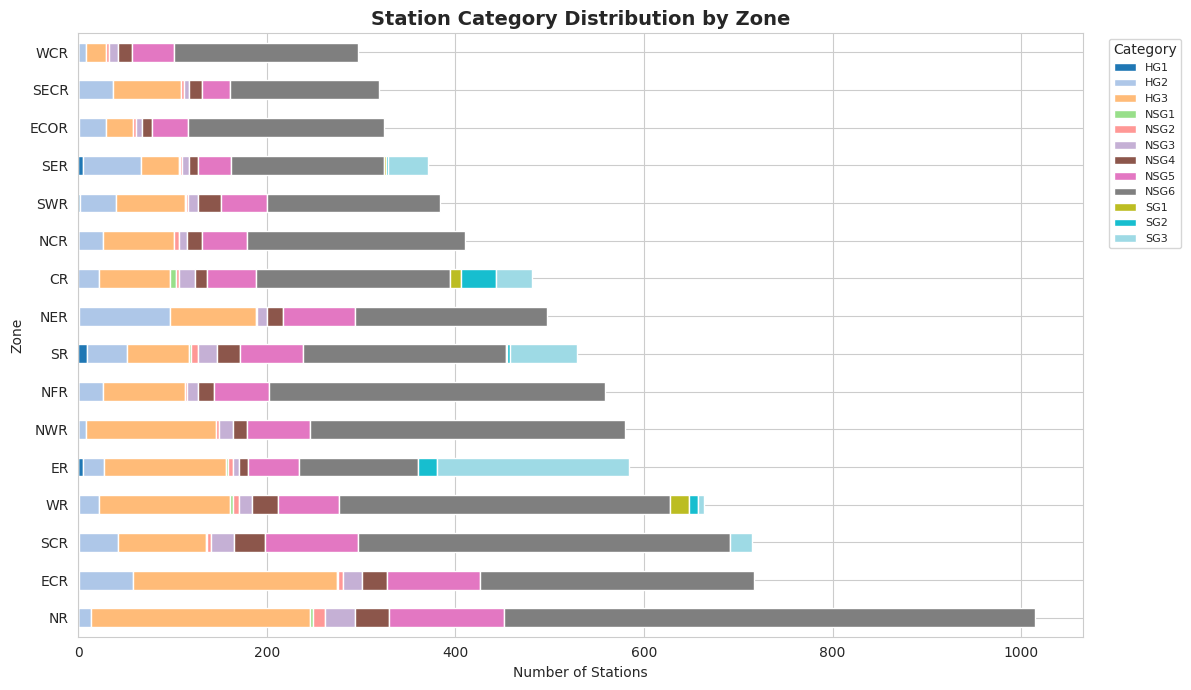

In [35]:
# 2. Category distribution across Zones (stacked bar)
category_zone = pd.crosstab(df['Zone'], df['Station Category'])

# Order columns by hierarchy for a sensible stack order
category_order = ['HG1','HG2','HG3','NSG1','NSG2','NSG3','NSG4','NSG5','NSG6','SG1','SG2','SG3']
category_zone = category_zone[[c for c in category_order if c in category_zone.columns]]

category_zone = category_zone.loc[category_zone.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12,7))
category_zone.plot(kind='barh', stacked=True, colormap='tab20', ax=plt.gca())
plt.title("Station Category Distribution by Zone", fontsize=14, weight='bold')
plt.xlabel("Number of Stations")
plt.ylabel("Zone")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("category_by_zone.png", dpi=150)
plt.show()

Zone ECR consist of highest number of top tier station.

Zone WCR consists of less amount of top tier station. WCR consist of MP and Rajasthan. Even though WCR falls under many zones but Category of the stations are least.

In [34]:
# Insight 6: Division size vs average station importance
div_avg = df.groupby('Division').agg(
    Station_Count=('Station Code','count'),
    Avg_Category_Rank=('Category_Rank','mean')
).sort_values('Avg_Category_Rank')
print("\nMost 'important' divisions (lowest avg rank):\n", div_avg.head(5))
print("\nLeast 'important' divisions (highest avg rank):\n", div_avg.tail(5))


Most 'important' divisions (lowest avg rank):
             Station_Count  Avg_Category_Rank
Division                                    
DANAPUR               219           5.278539
IZZATNAGAR            135           5.888889
ADRA                   97           6.010309
BANARAS               203           6.192118
VADODARA              120           6.208333

Least 'important' divisions (highest avg rank):
                  Station_Count  Avg_Category_Rank
Division                                         
SECUNDERABAD               145           8.434483
HOWRAH                     193           9.000000
SEALDAH                    206           9.106796
CHENNAI CENTRAL            160           9.118750
MUMBAI                     107           9.420561


/tmp/ipykernel_777/1822262446.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zone_counts.values, y=zone_counts.index, palette="viridis")


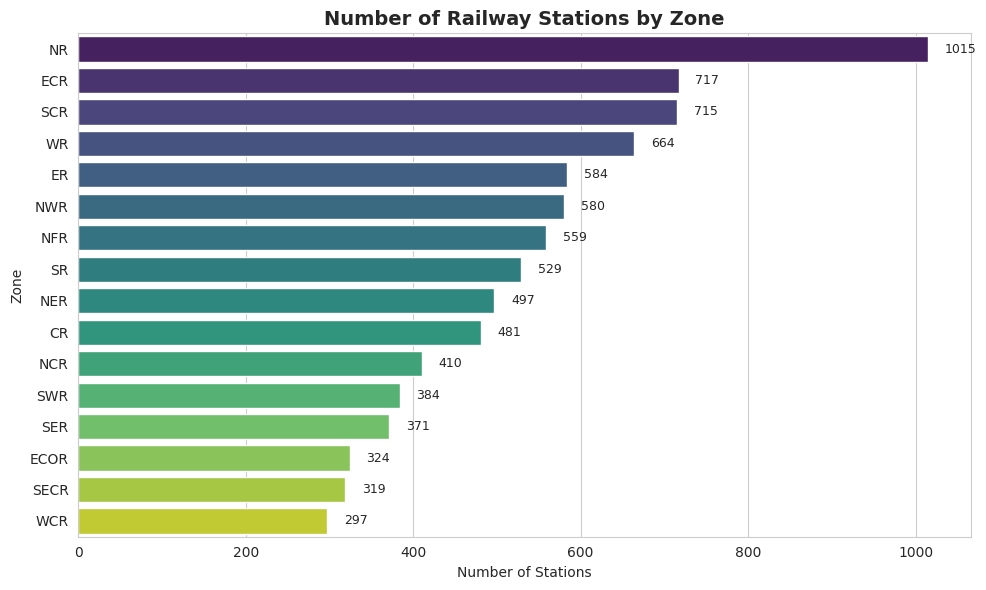

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Zone-wise station count
zone_counts = df['Zone'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=zone_counts.values, y=zone_counts.index, palette="viridis")
plt.title("Number of Railway Stations by Zone", fontsize=14, weight='bold')
plt.xlabel("Number of Stations")
plt.ylabel("Zone")
for i, v in enumerate(zone_counts.values):
    plt.text(v + 20, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig("zone_station_count.png", dpi=150)
plt.show()

NR, which consists of Delhi. Haryana, UP, and Punjab have the highest number of ralways_station.

And WCR zonw which consist of MP (falles under maxinum number of zones)Have the least number of station.

Which means just beacuse a state have fall under many zones or  does not mean it will have the most amount of railway stations.

In [37]:
df.to_csv('Railway_station_zone-category_wise_list_CLEANED.csv', index=False)

In [38]:
df.head()

,S No,Station Name,Station Code,Station Category,Division,Zone,District,State,Category_Rank,Division_Station_Count,Zone_Share_%
0,1,BHORAS BUDRUKH,BFJ,HG2,BHUSAWAL,CR,JALGAON,MAHARASHTRA,2,118,5.7
1,2,JAMNER,JMNR,HG2,BHUSAWAL,CR,JALGAON,MAHARASHTRA,2,118,5.7
2,3,ANJANGAON,ANJ,HG3,BHUSAWAL,CR,AMRAVATI,MAHARASHTRA,3,118,5.7
3,4,BANOSA,BASA,HG3,BHUSAWAL,CR,AMRAVATI,MAHARASHTRA,3,118,5.7
4,5,BHADSIVNI,BDKE,HG3,BHUSAWAL,CR,WASHIM,MAHARASHTRA,3,118,5.7


In [39]:
from google.colab import files
#files.download('Railway_station_zone-category_wise_list_CLEANED.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>